# Phase 2: Autograd — Automatic Differentiation

## What you'll learn
- How PyTorch tracks operations to compute gradients
- `requires_grad`, `.backward()`, `.grad`
- The computation graph
- Detaching and disabling gradients
- Gradient accumulation
- Custom autograd functions

---

## Why Autograd?

Deep learning = finding parameters that minimize a loss function.  
To minimize, we need **gradients** (derivatives).  
Autograd computes these **automatically** by recording every operation on tensors.

In [2]:
import torch

## 2.1 requires_grad — Telling PyTorch to Track Gradients

Set `requires_grad=True` on any tensor you want gradients for (typically model weights).

In [3]:
# Create a tensor that tracks gradients
x = torch.tensor(3.0, requires_grad=True)
print(f"x = {x}")
print(f"requires_grad = {x.requires_grad}")

# Comparison: Create a tensor WITHOUT gradient tracking to show the difference
x_no_grad = torch.tensor(3.0, requires_grad=False)
print(f"\nComparison - x_no_grad = {x_no_grad}")
print(f"x_no_grad.requires_grad = {x_no_grad.requires_grad}")

# Any operation on x creates a computation graph
y = x ** 2 + 2 * x + 1   # y = x² + 2x + 1
print(f"y = {y}")
print(f"y.grad_fn = {y.grad_fn}")  # shows the last operation

# Same operation on tensor without gradient tracking
y_no_grad = x_no_grad ** 2 + 2 * x_no_grad + 1
print(f"\nComparison - y_no_grad = {y_no_grad}")
print(f"y_no_grad.grad_fn = {y_no_grad.grad_fn}")  # This will be None - no computation graph!

# Visualize the difference: only tensors with requires_grad=True can compute gradients
print(f"\nKey Difference:")
print(f"y (from x with requires_grad=True) can compute gradients: {y.grad_fn is not None}")
print(f"y_no_grad (from x without requires_grad) cannot compute gradients: {y_no_grad.grad_fn is None}")


x = 3.0
requires_grad = True

Comparison - x_no_grad = 3.0
x_no_grad.requires_grad = False
y = 16.0
y.grad_fn = <AddBackward0 object at 0x0000019CADA3CA60>

Comparison - y_no_grad = 16.0
y_no_grad.grad_fn = None

Key Difference:
y (from x with requires_grad=True) can compute gradients: True
y_no_grad (from x without requires_grad) cannot compute gradients: True


In [5]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 2 * x + 1

# See the internal structure
print(x.storage())          # raw memory
print(x.stride())           # how to walk through dimensions
print(x.data_ptr())         # actual memory address (integer)
print(y.grad_fn)            # AddBackward0
print(y.grad_fn.next_functions)  # parent nodes in the graph


 3.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 1]
()
3612134674048
((<AddBackward0 object at 0x0000019CAF207190>, 0), (None, 0))


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_2212\2387744966.py:5: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(x.storage())          # raw memory


## 2.2 .backward() — Computing Gradients

Call `.backward()` on a scalar output to compute all gradients via the chain rule (backpropagation).

For `y = x² + 2x + 1`, the derivative is `dy/dx = 2x + 2`.  
At `x = 3`: `dy/dx = 2(3) + 2 = 8`.

dy/dx at x=3: 8.0


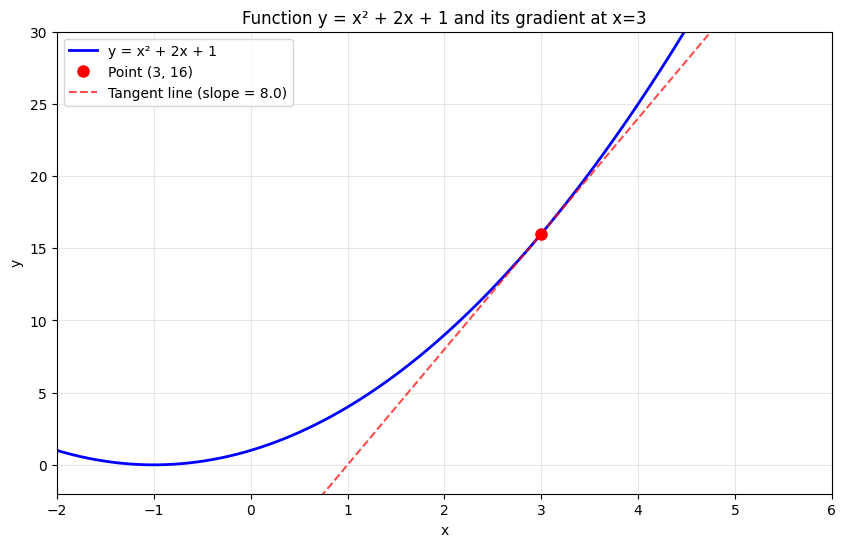


Step-by-step gradient calculation:
Function: y = x² + 2x + 1
Derivative: dy/dx = 2x + 2
At x = 3: dy/dx = 2(3) + 2 = 8
PyTorch computed gradient: 8.0


In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Create tensor with gradient tracking
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 2 * x + 1

# Compute gradients
y.backward()

# The gradient is stored in x.grad
print(f"dy/dx at x=3: {x.grad}")  # 8.0 ✓

# Visualization of the function and gradient
x_vals = np.linspace(-2, 6, 100)
y_vals = x_vals ** 2 + 2 * x_vals + 1

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', label='y = x² + 2x + 1', linewidth=2)
plt.plot(3, 16, 'ro', markersize=8, label='Point (3, 16)')

# Draw tangent line at x=3
tangent_slope = 8.0  # The computed gradient
tangent_y = 16 + tangent_slope * (x_vals - 3)
plt.plot(x_vals, tangent_y, 'r--', label=f'Tangent line (slope = {tangent_slope})', alpha=0.7)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Function y = x² + 2x + 1 and its gradient at x=3')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-2, 6)
plt.ylim(-2, 30)
plt.show()

# Step-by-step gradient calculation visualization
print("\nStep-by-step gradient calculation:")
print("Function: y = x² + 2x + 1")
print("Derivative: dy/dx = 2x + 2")
print(f"At x = 3: dy/dx = 2(3) + 2 = 8")
print(f"PyTorch computed gradient: {x.grad.item()}")


## 2.2.1 Visualizing backward() Step by Step

When you see `y.grad_fn = <AddBackward0 object at 0x...>`, it looks scary.
But it's just a **linked list of boxes**, each box knowing ONE thing:
"given the gradient flowing into me, what gradient do I pass to my parent?"

Let's walk through `y = x² + 2x + 1` at `x = 3` and see EXACTLY what happens:

```
FORWARD PASS (left → right, building the chain):

  [x=3]  →  [x²=9]  →  [x²+2x=15]  →  [x²+2x+1=16=y]
  (leaf)    PowBackward   AddBackward    AddBackward
             "I did x²"   "I added 2x"   "I added 1"


BACKWARD PASS (right → left, computing gradients):

  Step 1: Start at y. "How much does y change if y changes?" → 1
           (this is always 1 — the starting point)

  Step 2: AddBackward (y = something + 1)
           "Adding a constant doesn't change the slope"
           Pass gradient through unchanged: 1 × 1 = 1

  Step 3: AddBackward (something = x² + 2x)
           This SPLITS into two paths:
           Path A: x² → derivative is 2x = 2(3) = 6
           Path B: 2x → derivative is 2
           Both paths lead to x, so ADD them: 6 + 2 = 8

  Step 4: Store 8 in x.grad. Done!
```

The code below lets you SEE this chain by walking through `grad_fn.next_functions`.

In [8]:
import torch

# Build the computation graph
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 2 * x + 1

# === WALK THE GRAPH (before backward) ===
print("=== THE COMPUTATION GRAPH (what backward() will walk) ===\n")

# Start from y and walk backward through the chain
node = y.grad_fn
level = 0

def walk_graph(node, level=0):
    """Recursively walk and print the computation graph"""
    if node is None:
        return
    indent = "  " * level
    print(f"{indent}→ {type(node).__name__}")
    for child, _ in node.next_functions:
        if child is not None:
            walk_graph(child, level + 1)
        else:
            print(f"{indent}    → (leaf tensor: x)")

walk_graph(y.grad_fn)

# === NOW DO BACKWARD AND SEE THE RESULT ===
print("\n=== BACKWARD PASS (chain rule applied at each node) ===\n")
print("Starting gradient at y: 1.0")
print("  ↓ AddBackward0 (y = stuff + 1): d(stuff+1)/d(stuff) = 1 → pass 1.0")
print("  ↓ AddBackward0 (stuff = x² + 2x): SPLITS into two paths")
print("      Path A → PowBackward0 (x²): d(x²)/dx = 2x = 6.0")
print("      Path B → MulBackward0 (2*x): d(2x)/dx = 2.0")
print("  ↓ Both paths arrive at x, so ADD: 6.0 + 2.0 = 8.0")

y.backward()
print(f"\n✓ x.grad = {x.grad.item()}  (PyTorch confirms: 8.0)")

=== THE COMPUTATION GRAPH (what backward() will walk) ===

→ AddBackward0
  → AddBackward0
    → PowBackward0
      → AccumulateGrad
    → MulBackward0
      → AccumulateGrad
        → (leaf tensor: x)
    → (leaf tensor: x)

=== BACKWARD PASS (chain rule applied at each node) ===

Starting gradient at y: 1.0
  ↓ AddBackward0 (y = stuff + 1): d(stuff+1)/d(stuff) = 1 → pass 1.0
  ↓ AddBackward0 (stuff = x² + 2x): SPLITS into two paths
      Path A → PowBackward0 (x²): d(x²)/dx = 2x = 6.0
      Path B → MulBackward0 (2*x): d(2x)/dx = 2.0
  ↓ Both paths arrive at x, so ADD: 6.0 + 2.0 = 8.0

✓ x.grad = 8.0  (PyTorch confirms: 8.0)


### Key Takeaway

Each `grad_fn` is just a tiny function that knows:
1. **Who are my parents?** (via `next_functions`)
2. **What's my local derivative?** (e.g., PowBackward knows d(x²)/dx = 2x)
3. **Multiply incoming gradient × my local derivative, pass it up**

That's the **chain rule** happening automatically at each node.

```
grad_fn is NOT magic. It's just:

  AddBackward:  "I pass the gradient through unchanged (derivative of + is 1)"
  MulBackward:  "I multiply gradient by the other operand"
  PowBackward:  "I multiply gradient by n*x^(n-1)"

Each one is a simple rule. Chain them together = backpropagation.
```

## 2.3 Multi-variable Gradients

Autograd handles functions of multiple variables — it computes partial derivatives for each.

In [13]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

# z = a²b + b³
z = a**2 * b + b**3

print(f"z before backward : {z}")

z.backward()

# dz/da = 2ab = 2*2*3 = 12
print(f"dz/da = {a.grad}")  # 12.0

# dz/db = a² + 3b² = 4 + 27 = 31
print(f"dz/db = {b.grad}")  # 31.0

print(f"z after backward : {z}")

z before backward : 39.0
dz/da = 12.0
dz/db = 31.0
z after backward : 39.0


## 2.4 Gradients with Vectors

When working with vector outputs, you need to reduce to a scalar first (e.g., `.sum()` or `.mean()`).

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# y = x² (element-wise)
y = x ** 2

# Can't call y.backward() directly — y is not scalar
# Reduce to scalar first
loss = y.sum()  # or y.mean()

loss.backward()
# d(sum(x²))/dx = 2x
print(f"Gradients: {x.grad}")  # [2, 4, 6]
print(y)

tensor(14., grad_fn=<SumBackward0>)
Gradients: tensor([2., 4., 6.])
tensor([1., 4., 9.], grad_fn=<PowBackward0>)


## 2.5 The Computation Graph

PyTorch builds a **dynamic computation graph** (DAG) as you run operations.

```
x (leaf) → x² → +2x → +1 → y (output)
```

Key points:
- **Leaf tensors**: created by the user (e.g., `x`)
- **Non-leaf tensors**: results of operations (e.g., `y`)
- The graph is **destroyed after `.backward()`** (one-time use)
- Use `retain_graph=True` if you need to call `.backward()` again

In [20]:
x = torch.tensor(2.0, requires_grad=True)
y = x * 3
z = y ** 2

print(f"x is leaf: {x.is_leaf}")   # True
print(f"y is leaf: {y.is_leaf}")   # False
print(f"z is leaf: {z.is_leaf}")   # False
print(f"y.grad_fn: {y.grad_fn}")   # MulBackward0
print(f"z.grad_fn: {z.grad_fn}")   # PowBackward0

z.backward()
print(f"\ndz/dx = {x.grad}")  # dz/dx = 2*(3x)*3 = 18x = 36

x is leaf: True
y is leaf: False
z is leaf: False
y.grad_fn: <MulBackward0 object at 0x000002BDEFE7E4A0>
z.grad_fn: <PowBackward0 object at 0x000002BDEFE7E4A0>

dz/dx = 36.0


## 2.6 Gradient Accumulation & Zeroing

**Critical concept**: PyTorch **accumulates** gradients by default. You must zero them before each backward pass.

In [27]:
x = torch.tensor(2.0, requires_grad=True)

# First backward
y1 = x ** 2
y1.backward()
print(f"After 1st backward: {x.grad}")  # 4.0

# Second backward WITHOUT zeroing — gradients accumulate!
y2 = x ** 2
y2.backward()
print(f"After 2nd backward (accumulated): {x.grad}")  # 8.0 (4+4)

# Correct approach: zero gradients first
x.grad.zero_()
y3 = x ** 2
y3.backward()
print(f"After zeroing + backward: {x.grad}")  # 4.0 ✓

After 1st backward: 4.0
After 2nd backward (accumulated): 8.0
After zeroing + backward: 4.0


## 2.7 Disabling Gradient Tracking

During inference or evaluation, you don't need gradients. Disabling them saves memory and speeds things up.

Three ways to do it:

In [37]:
x = torch.tensor(3.0, requires_grad=True)

# Method 1: torch.no_grad() context manager
with torch.no_grad():
    y = x * 2
    print(f"no_grad — y.requires_grad: {y.requires_grad}")  # False

# Method 2: .detach() — creates a new tensor without grad
z = x.detach()
print(f"detach — z.requires_grad: {z.requires_grad}")  # False

# Method 3: set requires_grad directly
a = torch.tensor(5.0, requires_grad=True)
a.requires_grad_(False)
print(f"requires_grad_(False): {a.requires_grad}")  # False

no_grad — y.requires_grad: False
detach — z.requires_grad: False
requires_grad_(False): False


## 2.8 Practical Example: Manual Linear Regression

Let's use autograd to train a simple linear model `y = wx + b` from scratch.

In [38]:
# Generate synthetic data: y = 3x + 1 + noise
torch.manual_seed(42)
X = torch.rand(100, 1) * 10
y_true = 3 * X + 1 + torch.randn(100, 1) * 0.5

# Initialize learnable parameters
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01

# Training loop
for epoch in range(100):
    # Forward pass
    y_pred = w * X + b
    loss = ((y_pred - y_true) ** 2).mean()  # MSE

    # Backward pass
    loss.backward()

    # Update weights (no_grad because we don't want to track this)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Zero gradients
    w.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: loss={loss.item():.4f}, w={w.item():.4f}, b={b.item():.4f}")

print(f"\nLearned: y = {w.item():.2f}x + {b.item():.2f}")
print(f"True:    y = 3.00x + 1.00")

Epoch 20: loss=0.2549, w=3.0656, b=0.5141
Epoch 40: loss=0.2394, w=3.0575, b=0.5690
Epoch 60: loss=0.2265, w=3.0502, b=0.6189
Epoch 80: loss=0.2159, w=3.0435, b=0.6643
Epoch 100: loss=0.2072, w=3.0374, b=0.7055

Learned: y = 3.04x + 0.71
True:    y = 3.00x + 1.00


## 2.9 Custom Autograd Function (Advanced)

You can define custom forward/backward passes by subclassing `torch.autograd.Function`.

In [39]:
class MyReLU(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        # ctx is a context object to save info for backward
        ctx.save_for_backward(x)
        return x.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        grad = grad_output.clone()
        grad[x < 0] = 0  # gradient is 0 where x < 0
        return grad

# Usage
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0], requires_grad=True)
y = MyReLU.apply(x)
y.sum().backward()

print(f"Input:    {x.data}")
print(f"Output:   {y.data}")
print(f"Gradient: {x.grad}")  # [0, 0, 0, 1, 1]

Input:    tensor([-2., -1.,  0.,  1.,  2.])
Output:   tensor([0., 0., 0., 1., 2.])
Gradient: tensor([0., 0., 1., 1., 1.])


## ✅ Phase 2 Summary

You now understand:
- `requires_grad=True` tells PyTorch to track operations
- `.backward()` computes gradients via backpropagation
- `.grad` stores the computed gradient on leaf tensors
- Gradients **accumulate** — always zero them before each step
- Use `torch.no_grad()` or `.detach()` to stop tracking
- The computation graph is dynamic and rebuilt each forward pass

**Next → Phase 3: Neural Network Building Blocks (nn.Module)**